# **FINAL RISK PREDICTION HEAD**

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount="true")

Mounted at /content/drive


In [ ]:
# ======================================================
# MULTI-FACTOR ICU RISK PREDICTION
# ======================================================

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    matthews_corrcoef,
    brier_score_loss
)

# ======================================================
# PATHS
# ======================================================

BASE_PATH = "/content/drive/MyDrive/MIMIC_Extracted"

FUSED_PATH = os.path.join(BASE_PATH,"fused_embeddings.npz")
ADMISSIONS_PATH = os.path.join(BASE_PATH,"ADMISSIONS.csv")
ICUSTAYS_PATH = os.path.join(BASE_PATH,"ICUSTAYS.csv")

# ======================================================
# LOAD FUSED EMBEDDINGS
# ======================================================

data = np.load(FUSED_PATH)

ids = data["ids"]
fused = data["fused"]

print("Fused embeddings:", fused.shape)

# ======================================================
# LOAD CLINICAL DATA
# ======================================================

admissions = pd.read_csv(ADMISSIONS_PATH)
icustays = pd.read_csv(ICUSTAYS_PATH)

df = icustays.merge(
    admissions[[
        "hadm_id",
        "hospital_expire_flag",
        "admission_type",
        "admission_location",
        "insurance"
    ]],
    on="hadm_id",
    how="left"
)

# ======================================================
# ICU LENGTH OF STAY
# ======================================================

df["intime"] = pd.to_datetime(df["intime"])
df["outtime"] = pd.to_datetime(df["outtime"])

df["icu_los_hours"] = (
    df["outtime"] - df["intime"]
).dt.total_seconds()/3600

# ======================================================
# ENCODE CATEGORICAL FEATURES
# ======================================================

df["admission_type"] = df["admission_type"].astype("category").cat.codes
df["admission_location"] = df["admission_location"].astype("category").cat.codes
df["insurance"] = df["insurance"].astype("category").cat.codes

feature_map = df.set_index("icustay_id")

# ======================================================
# CREATE MULTI-FACTOR RISK LABEL
# ======================================================

extra_features = []
labels = []

for i in ids:

    if i in feature_map.index:

        row = feature_map.loc[i]

        death = row["hospital_expire_flag"]

        icu_los = row["icu_los_hours"]
        long_stay = 1 if icu_los > 72 else 0

        emergency = 1 if row["admission_type"] == 0 else 0

        risk = (
            0.6 * death +
            0.2 * long_stay +
            0.2 * emergency
        )

        labels.append(risk)

        extra_features.append([
            row["admission_type"],
            row["admission_location"],
            row["insurance"],
            icu_los
        ])

    else:

        labels.append(0)
        extra_features.append([0,0,0,0])

extra_features = np.array(extra_features)
labels = np.array(labels)

print("Extra features:",extra_features.shape)

# ======================================================
# COMBINE FEATURES
# ======================================================

X = np.concatenate([fused,extra_features],axis=1)

print("Final feature shape:",X.shape)

# ======================================================
# NORMALIZE
# ======================================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ======================================================
# TRAIN TEST SPLIT
# ======================================================

X_train,X_test,y_train,y_test = train_test_split(
    X,
    labels,
    test_size=0.25,
    random_state=42
)

X_train = torch.tensor(X_train,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

# ======================================================
# MODEL
# ======================================================

class RiskPredictionModel(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,32),
            nn.ReLU(),

            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self,x):

        return self.model(x)

model = RiskPredictionModel(X.shape[1])

print(model)

# ======================================================
# LOSS + OPTIMIZER
# ======================================================

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# ======================================================
# TRAINING
# ======================================================

EPOCHS = 400

loss_history = []

for epoch in range(EPOCHS):

    model.train()

    preds = model(X_train).squeeze()

    loss = criterion(preds,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 10 == 0:
        print("Epoch",epoch,"Loss",loss.item())




# ======================================================
# SAVE RISK SCORES
# ======================================================

with torch.no_grad():

    risk_scores = model(torch.tensor(X,dtype=torch.float32)).squeeze().numpy()

risk_df = pd.DataFrame({

    "icustay_id":ids,
    "risk_score":risk_scores
})

risk_df.to_csv(

    os.path.join(BASE_PATH,"risk_scores_final1.csv"),
    index=False
)

print("Risk scores saved")

Fused embeddings: (993, 768)
Extra features: (993, 4)
Final feature shape: (993, 772)
RiskPredictionModel(
  (model): Sequential(
    (0): Linear(in_features=772, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=32, bias=True)
    (11): ReLU()
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)
Epoch 0 Loss 0.6968432068824768
Epoch 10 Loss 0.6487376689910889
Epoch 20 Loss 0.6075868010520935
Epoch 30 Loss 0.5730457305908203
Epoch 40 Loss 0.5462291836738586
Epoch 50 Loss 0.5240892171859741
Epoch 60 Loss 0.

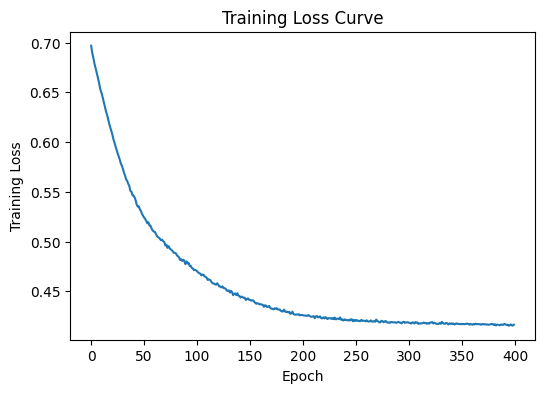

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")

plt.show()

In [ ]:
# ======================================================
# EVALUATION
# ======================================================

model.eval()

with torch.no_grad():

    preds = model(X_test).squeeze().numpy()

y_true = y_test.numpy()

# Binary labels
binary_labels = (y_true > 0.4).astype(int)

# AUC
auc = roc_auc_score(binary_labels,preds)

# ======================================================
# BEST THRESHOLD SEARCH
# ======================================================

best_acc = 0
best_thresh = 0

for t in np.linspace(0.1,0.9,100):

    pred_bin = (preds > t).astype(int)

    acc = accuracy_score(binary_labels,pred_bin)

    if acc > best_acc:

        best_acc = acc
        best_thresh = t

# Final predictions using best threshold
final_preds = (preds > best_thresh).astype(int)

mcc = matthews_corrcoef(binary_labels,final_preds)
brier = brier_score_loss(binary_labels,preds)

# ======================================================
# PRINT METRICS
# ======================================================

print("\nMODEL PERFORMANCE")


print("Accuracy:",best_acc)
print("Brier Score:",brier)
print("MCC:",mcc)



MODEL PERFORMANCE
Accuracy: 0.9196787148594378
Brier Score: 0.09593668562284352
MCC: 0.3923843496159123


In [ ]:
print("AUC:",auc)

AUC: 0.8726027397260274


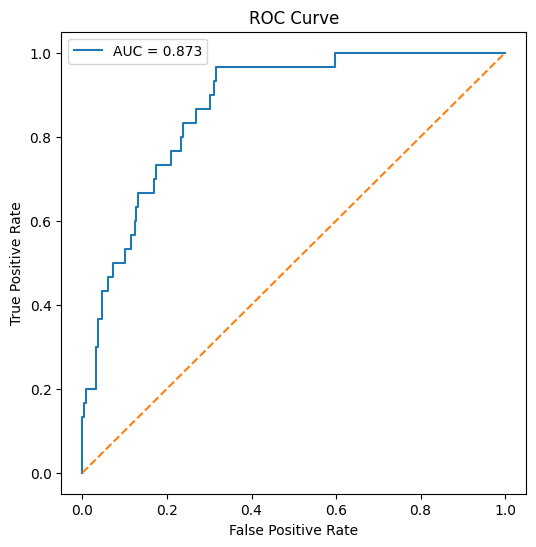

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()